# 01. Новый baseline без `Q_B1_norm` и `Q_B2_norm`

## Главный исследовательский вопрос

**Какой честный уровень качества дают CatBoost, XGBoost и LightGBM после полного исключения `Q_B1_norm` и `Q_B2_norm` при одном и том же протоколе оценки?**

### Контролируемый эксперимент

Для всех трёх моделей фиксируются одинаковые:

- dataset и SHA-256;
- target `DefMark`;
- 47 допустимых признаков;
- final test 20%;
- рабочая выборка 80%;
- `StratifiedKFold` на 3 фолда;
- `random_state = 42`;
- отсутствие весов классов;
- отсутствие Optuna;
- отсутствие калибровки;
- отсутствие подбора порога;
- порог `0.5` используется только для диагностических Precision / Recall / F1;
- final test не используется для выбора модели.

Главные метрики: **Gini, ROC-AUC, PR-AUC**. Дополнительно фиксируются Precision, Recall, F1, confusion matrix и время работы.

### Что этот эксперимент не доказывает

Random split не доказывает temporal stability. Эксперимент не выбирает промышленный threshold и не оценивает бизнес-стоимость ошибок.


# 1. Окружение и конфигурация

## Исследовательский вопрос

Работаем ли мы в ожидаемом проектном окружении и зафиксированы ли параметры эксперимента до просмотра результатов?


In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata as importlib_metadata
import json
import platform
from pathlib import Path
from time import perf_counter
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier, early_stopping
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from xgboost import XGBClassifier


def найти_корень_проекта(начало: Path | None = None) -> Path:
    """Находит корень проекта по файлу pyproject.toml."""
    текущая = (начало or Path.cwd()).resolve()
    for кандидат in [текущая, *текущая.parents]:
        if (кандидат / "pyproject.toml").exists():
            return кандидат
    raise FileNotFoundError("Не найден корень проекта с pyproject.toml.")


def вычислить_sha256(путь: Path, размер_блока: int = 1024 * 1024) -> str:
    """Вычисляет SHA-256 файла блоками."""
    хэш = hashlib.sha256()
    with путь.open("rb") as файл:
        for блок in iter(lambda: файл.read(размер_блока), b""):
            хэш.update(блок)
    return хэш.hexdigest()


def хэш_массива(значения: np.ndarray) -> str:
    """Вычисляет SHA-256 массива индексов split."""
    массив = np.asarray(значения, dtype=np.int64)
    return hashlib.sha256(массив.tobytes()).hexdigest()


КОРЕНЬ_ПРОЕКТА = найти_корень_проекта()
ПУТЬ_К_ДАТАСЕТУ = КОРЕНЬ_ПРОЕКТА / "data" / "raw" / "Data_final.xlsb"
ПАПКА_ОТЧЁТОВ = КОРЕНЬ_ПРОЕКТА / "reports" / "generated"
ПАПКА_ОТЧЁТОВ.mkdir(parents=True, exist_ok=True)

ОЖИДАЕМЫЙ_SHA256 = "fc742be66d238c529daba52ccc755f774f836b7d052ed062cdf0b345080e7930"

ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ = "DefMark"
ИДЕНТИФИКАТОР = "INN"
ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ = ["Q_B1_norm", "Q_B2_norm"]

ДОЛЯ_ФИНАЛЬНОГО_TEST = 0.20
ЧИСЛО_ФОЛДОВ = 3
СЛУЧАЙНОЕ_ЗЕРНО = 42
РАННЯЯ_ОСТАНОВКА = 40
ДОЛЯ_ВНУТРЕННЕЙ_ВАЛИДАЦИИ = 0.10
ЧИСЛО_ПОТОКОВ = -1

print("Корень проекта:", КОРЕНЬ_ПРОЕКТА)
print("Python:", platform.python_version())
print("Dataset:", ПУТЬ_К_ДАТАСЕТУ)
print("Final test:", f"{ДОЛЯ_ФИНАЛЬНОГО_TEST:.0%}")
print("CV:", f"{ЧИСЛО_ФОЛДОВ} стратифицированных фолда")
print("Seed:", СЛУЧАЙНОЕ_ЗЕРНО)
print("Внутренняя validation для early stopping:", f"{ДОЛЯ_ВНУТРЕННЕЙ_ВАЛИДАЦИИ:.0%} от train-фолда")


Корень проекта: D:\Projects\komus-credit-risk
Python: 3.12.2
Dataset: D:\Projects\komus-credit-risk\data\raw\Data_final.xlsb
Final test: 20%
CV: 3 стратифицированных фолда
Seed: 42
Внутренняя validation для early stopping: 10% от train-фолда


### Анализ настройки

Конфигурация выше является частью экспериментального контракта. Изменение dataset, feature set, split, seed, параметров моделей или протокола оценки создаёт уже другой эксперимент.


# 2. Датасет и допустимый feature set

## Исследовательский вопрос

Используется ли зафиксированный dataset заказчика и исключены ли `Q_B1_norm` и `Q_B2_norm` **до** любого обучения?


In [2]:
if not ПУТЬ_К_ДАТАСЕТУ.exists():
    raise FileNotFoundError(f"Dataset не найден: {ПУТЬ_К_ДАТАСЕТУ}")

фактический_sha256 = вычислить_sha256(ПУТЬ_К_ДАТАСЕТУ)

if фактический_sha256.lower() != ОЖИДАЕМЫЙ_SHA256.lower():
    raise RuntimeError(
        "SHA-256 dataset не совпал с зафиксированной версией.\n"
        f"Ожидался: {ОЖИДАЕМЫЙ_SHA256}\n"
        f"Получен:  {фактический_sha256}"
    )

начало_чтения = perf_counter()

данные = pd.read_excel(
    ПУТЬ_К_ДАТАСЕТУ,
    engine="pyxlsb",
    sheet_name="Data_final",
).reset_index(drop=True)

время_чтения = perf_counter() - начало_чтения

обязательные = {ИДЕНТИФИКАТОР, ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ, *ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ}
отсутствующие = обязательные.difference(данные.columns)
if отсутствующие:
    raise KeyError(f"Отсутствуют обязательные столбцы: {sorted(отсутствующие)}")

данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ] = pd.to_numeric(
    данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ],
    errors="raise",
).astype("int8")

ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ = [
    столбец
    for столбец in данные.columns
    if столбец not in {ИДЕНТИФИКАТОР, ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ}
]

ДОПУСТИМЫЕ_ПРИЗНАКИ = [
    столбец
    for столбец in ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ
    if столбец not in ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ
]

for столбец in ДОПУСТИМЫЕ_ПРИЗНАКИ:
    данные[столбец] = pd.to_numeric(
        данные[столбец],
        errors="raise",
    ).astype("float32")

if len(ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ) != 49:
    raise RuntimeError(
        f"Ожидалось 49 исходных признаков, получено {len(ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ)}."
    )

if len(ДОПУСТИМЫЕ_ПРИЗНАКИ) != 47:
    raise RuntimeError(
        f"Ожидалось 47 допустимых признаков, получено {len(ДОПУСТИМЫЕ_ПРИЗНАКИ)}."
    )

if set(ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ).intersection(ДОПУСТИМЫЕ_ПРИЗНАКИ):
    raise RuntimeError("Закрытые индексы попали в допустимый feature set.")

уникальные_классы = sorted(
    данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ].dropna().unique().tolist()
)
if уникальные_классы != [0, 1]:
    raise RuntimeError(f"Неожиданные значения target: {уникальные_классы}")

ПАСПОРТ_ДАННЫХ = pd.DataFrame([
    ("SHA-256", фактический_sha256),
    ("Строк", len(данные)),
    ("Столбцов", данные.shape[1]),
    ("Исходных модельных признаков", len(ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ)),
    ("Допустимых признаков", len(ДОПУСТИМЫЕ_ПРИЗНАКИ)),
    ("Исключено", ", ".join(ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ)),
    ("Доля дефолтов, %", float(данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ].mean() * 100)),
    ("Пропусков в допустимых признаках", int(данные[ДОПУСТИМЫЕ_ПРИЗНАКИ].isna().sum().sum())),
    ("Дубликатов INN", int(данные[ИДЕНТИФИКАТОР].duplicated().sum())),
    ("Время чтения, сек", float(время_чтения)),
], columns=["Проверка", "Значение"])

display(ПАСПОРТ_ДАННЫХ)


,Проверка,Значение
0,SHA-256,fc742be66d238c529daba52ccc755f774f836b7d052ed0...
1,Строк,362018
2,Столбцов,51
3,Исходных модельных признаков,49
4,Допустимых признаков,47
5,Исключено,"Q_B1_norm, Q_B2_norm"
6,"Доля дефолтов, %",9.673276
7,Пропусков в допустимых признаках,0
8,Дубликатов INN,0
9,"Время чтения, сек",124.99685


In [3]:
display(Markdown(f"""
### Анализ полученного результата

- Dataset подтверждён по **SHA-256**: `{фактический_sha256}`.
- Исходный набор содержит **{len(ВСЕ_МОДЕЛЬНЫЕ_ПРИЗНАКИ)} модельных признаков**.
- `Q_B1_norm` и `Q_B2_norm` исключены **до формирования рабочего feature set**.
- В эксперимент допускаются **{len(ДОПУСТИМЫЕ_ПРИЗНАКИ)} признаков**.
- Доля дефолтов: **{данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ].mean() * 100:.2f}%**.

**Вывод:** модели ниже никогда не получают `Q_B1_norm` или `Q_B2_norm`.
"""))



### Анализ полученного результата

- Dataset подтверждён по **SHA-256**: `fc742be66d238c529daba52ccc755f774f836b7d052ed062cdf0b345080e7930`.
- Исходный набор содержит **49 модельных признаков**.
- `Q_B1_norm` и `Q_B2_norm` исключены **до формирования рабочего feature set**.
- В эксперимент допускаются **47 признаков**.
- Доля дефолтов: **9.67%**.

**Вывод:** модели ниже никогда не получают `Q_B1_norm` или `Q_B2_norm`.


# 3. Final test и кросс-валидация

## Исследовательский вопрос

Можно ли сформировать одинаковые воспроизводимые разбиения для всех моделей и не использовать final test для выбора?


In [4]:
X_все = данные[ДОПУСТИМЫЕ_ПРИЗНАКИ]
y_все = данные[ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ]

индексы = np.arange(len(данные))

индексы_работа, индексы_test = train_test_split(
    индексы,
    test_size=ДОЛЯ_ФИНАЛЬНОГО_TEST,
    stratify=y_все,
    random_state=СЛУЧАЙНОЕ_ЗЕРНО,
)

# Final test сознательно не материализуется в X_test / y_test.
# Его индексы фиксируются только для будущей единственной финальной проверки.
X_работа = X_все.iloc[индексы_работа].reset_index(drop=True)
y_работа = y_все.iloc[индексы_работа].reset_index(drop=True)

КРОСС_ВАЛИДАЦИЯ = StratifiedKFold(
    n_splits=ЧИСЛО_ФОЛДОВ,
    shuffle=True,
    random_state=СЛУЧАЙНОЕ_ЗЕРНО,
)

ФОЛДЫ = list(КРОСС_ВАЛИДАЦИЯ.split(X_работа, y_работа))

строки = [
    {
        "Часть": "Рабочая выборка",
        "Строк": len(индексы_работа),
        "Доля дефолтов, %": float(y_работа.mean() * 100),
    },
    {
        "Часть": "Final test — закрыт",
        "Строк": len(индексы_test),
        "Доля дефолтов, %": np.nan,
    },
]

for номер, (train_idx, valid_idx) in enumerate(ФОЛДЫ, start=1):
    строки.extend([
        {
            "Часть": f"Фолд {номер}: обучение",
            "Строк": len(train_idx),
            "Доля дефолтов, %": float(y_работа.iloc[train_idx].mean() * 100),
        },
        {
            "Часть": f"Фолд {номер}: проверка",
            "Строк": len(valid_idx),
            "Доля дефолтов, %": float(y_работа.iloc[valid_idx].mean() * 100),
        },
    ])

ТАБЛИЦА_РАЗБИЕНИЯ = pd.DataFrame(строки)
ТАБЛИЦА_РАЗБИЕНИЯ_ПОКАЗ = ТАБЛИЦА_РАЗБИЕНИЯ.copy()
ТАБЛИЦА_РАЗБИЕНИЯ_ПОКАЗ["Доля дефолтов, %"] = (
    ТАБЛИЦА_РАЗБИЕНИЯ_ПОКАЗ["Доля дефолтов, %"]
    .map(lambda x: "не открывается" if pd.isna(x) else f"{x:.3f}")
)
display(ТАБЛИЦА_РАЗБИЕНИЯ_ПОКАЗ)

SHA_ИНДЕКСОВ_РАБОТА = хэш_массива(индексы_работа)
SHA_ИНДЕКСОВ_TEST = хэш_массива(индексы_test)

print("SHA-256 индексов рабочей выборки:", SHA_ИНДЕКСОВ_РАБОТА)
print("SHA-256 индексов final test:", SHA_ИНДЕКСОВ_TEST)
print("Final test создан, но не используется в модельном сравнении.")


,Часть,Строк,"Доля дефолтов, %"
0,Рабочая выборка,289614,9.673
1,Final test — закрыт,72404,не открывается
2,Фолд 1: обучение,193076,9.673
3,Фолд 1: проверка,96538,9.673
4,Фолд 2: обучение,193076,9.673
5,Фолд 2: проверка,96538,9.673
6,Фолд 3: обучение,193076,9.673
7,Фолд 3: проверка,96538,9.674


SHA-256 индексов рабочей выборки: 80430ce6290d0982d3641621ba1ed62f6fb495e8d32f7d23d9fca00091aadb45
SHA-256 индексов final test: 35ec963fe82918841f4a8acb012e8fc878aed66d2c5296ea6cb105177cafbb37
Final test создан, но не используется в модельном сравнении.


### Анализ разбиения

Все три модели используют одни и те же рабочие строки и CV-фолды. Final test уже определён и не может быть переигран после просмотра результатов. На Stage 1 решения принимаются только по OOF/CV рабочей выборки.


# 4. CatBoost, XGBoost и LightGBM на одном feature set

## Исследовательский вопрос

Какая из трёх CPU-моделей показывает лучший воспроизводимый OOF-результат без закрытых индексов при фиксированных стартовых параметрах?

На этом этапе параметры **не подбираются**. Мы измеряем исходный уровень качества, а не ищем максимум.

### Как устроен early stopping

Внешний validation-фолд используется **только для итоговой оценки**.

Внутри каждого train-фолда отдельно выделяется небольшая стратифицированная validation-часть. На ней определяется число boosting-итераций. После этого модель заново обучается на **всём внешнем train-фолде** с уже зафиксированным числом итераций и только затем делает прогноз на внешнем validation-фолде.

Так метки внешнего validation-фолда не влияют на выбор числа деревьев.


In [5]:
ПАРАМЕТРЫ_МОДЕЛЕЙ: dict[str, dict[str, Any]] = {
    "CatBoost": {
        "iterations": 900,
        "learning_rate": 0.06,
        "depth": 7,
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "thread_count": ЧИСЛО_ПОТОКОВ,
        "verbose": False,
        "allow_writing_files": False,
    },
    "XGBoost": {
        "n_estimators": 900,
        "learning_rate": 0.06,
        "max_depth": 6,
        "min_child_weight": 3,
        "subsample": 0.85,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.05,
        "reg_lambda": 1.0,
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_jobs": ЧИСЛО_ПОТОКОВ,
        "tree_method": "hist",
    },
    "LightGBM": {
        "n_estimators": 900,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 40,
        "subsample": 0.85,
        "subsample_freq": 1,
        "colsample_bytree": 0.85,
        "reg_alpha": 0.05,
        "reg_lambda": 1.0,
        "n_jobs": ЧИСЛО_ПОТОКОВ,
        "verbosity": -1,
    },
}


def рассчитать_метрики(
    истинные_классы: pd.Series | np.ndarray,
    вероятности: np.ndarray,
    порог: float = 0.5,
) -> dict[str, Any]:
    """Рассчитывает ранжирующие и пороговые метрики."""
    y_true = np.asarray(истинные_классы, dtype=int)
    y_score = np.asarray(вероятности, dtype=float)
    y_pred = (y_score >= порог).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    roc_auc = float(roc_auc_score(y_true, y_score))

    return {
        "ROC-AUC": roc_auc,
        "Gini": float(2 * roc_auc - 1),
        "PR-AUC": float(average_precision_score(y_true, y_score)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def внутреннее_разбиение(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Создаёт внутреннюю validation-часть только внутри внешнего train-фолда."""
    индексы = np.arange(len(X_train))
    индексы_fit, индексы_early_stop = train_test_split(
        индексы,
        test_size=ДОЛЯ_ВНУТРЕННЕЙ_ВАЛИДАЦИИ,
        stratify=y_train,
        random_state=seed,
    )

    return (
        X_train.iloc[индексы_fit],
        X_train.iloc[индексы_early_stop],
        y_train.iloc[индексы_fit],
        y_train.iloc[индексы_early_stop],
    )


def обучить_и_предсказать(
    название: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    seed: int,
) -> tuple[np.ndarray, int, float, float]:
    """
    Сначала выбирает число итераций на внутренней validation-части,
    затем переобучает модель на всём внешнем train-фолде и прогнозирует
    внешний validation-фолд.
    """
    X_fit, X_early_stop, y_fit, y_early_stop = внутреннее_разбиение(
        X_train,
        y_train,
        seed,
    )

    начало_обучения = perf_counter()

    if название == "CatBoost":
        параметры_поиска = ПАРАМЕТРЫ_МОДЕЛЕЙ["CatBoost"].copy()

        модель_поиска_catboost = CatBoostClassifier(
            **параметры_поиска,
            random_seed=seed,
        )
        модель_поиска_catboost.fit(
            X_fit,
            y_fit,
            eval_set=(X_early_stop, y_early_stop),
            early_stopping_rounds=РАННЯЯ_ОСТАНОВКА,
            verbose=False,
        )

        лучшая = модель_поиска_catboost.get_best_iteration()
        число_итераций = (
            int(лучшая) + 1
            if лучшая is not None and int(лучшая) >= 0
            else int(параметры_поиска["iterations"])
        )

        параметры_финала = параметры_поиска.copy()
        параметры_финала["iterations"] = число_итераций

        модель_catboost = CatBoostClassifier(
            **параметры_финала,
            random_seed=seed,
        )
        модель_catboost.fit(X_train, y_train)

        время_обучения = perf_counter() - начало_обучения
        начало_прогноза = perf_counter()

        матрица_вероятностей = np.asarray(
            модель_catboost.predict_proba(X_valid),
            dtype=float,
        )
        вероятности = матрица_вероятностей[:, 1]

        время_прогноза = perf_counter() - начало_прогноза
        return вероятности, число_итераций, время_обучения, время_прогноза

    if название == "XGBoost":
        параметры_поиска = ПАРАМЕТРЫ_МОДЕЛЕЙ["XGBoost"].copy()

        модель_поиска_xgboost = XGBClassifier(
            **параметры_поиска,
            random_state=seed,
            early_stopping_rounds=РАННЯЯ_ОСТАНОВКА,
        )
        модель_поиска_xgboost.fit(
            X_fit,
            y_fit,
            eval_set=[(X_early_stop, y_early_stop)],
            verbose=False,
        )

        лучшая = getattr(модель_поиска_xgboost, "best_iteration", None)
        число_итераций = (
            int(лучшая) + 1
            if лучшая is not None
            else int(параметры_поиска["n_estimators"])
        )

        параметры_финала = параметры_поиска.copy()
        параметры_финала["n_estimators"] = число_итераций

        модель_xgboost = XGBClassifier(
            **параметры_финала,
            random_state=seed,
        )
        модель_xgboost.fit(X_train, y_train)

        время_обучения = perf_counter() - начало_обучения
        начало_прогноза = perf_counter()

        матрица_вероятностей = np.asarray(
            модель_xgboost.predict_proba(X_valid),
            dtype=float,
        )
        вероятности = матрица_вероятностей[:, 1]

        время_прогноза = perf_counter() - начало_прогноза
        return вероятности, число_итераций, время_обучения, время_прогноза

    if название == "LightGBM":
        параметры_поиска = ПАРАМЕТРЫ_МОДЕЛЕЙ["LightGBM"].copy()

        модель_поиска_lightgbm = LGBMClassifier(
            **параметры_поиска,
            random_state=seed,
        )
        модель_поиска_lightgbm.fit(
            X_fit,
            y_fit,
            eval_X=X_early_stop,
            eval_y=y_early_stop,
            callbacks=[early_stopping(РАННЯЯ_ОСТАНОВКА, verbose=False)],
        )

        лучшая = getattr(модель_поиска_lightgbm, "best_iteration_", None)
        число_итераций = (
            int(лучшая)
            if лучшая is not None and int(лучшая) > 0
            else int(параметры_поиска["n_estimators"])
        )

        параметры_финала = параметры_поиска.copy()
        параметры_финала["n_estimators"] = число_итераций

        модель_lightgbm = LGBMClassifier(
            **параметры_финала,
            random_state=seed,
        )
        модель_lightgbm.fit(X_train, y_train)

        время_обучения = perf_counter() - начало_обучения
        начало_прогноза = perf_counter()

        матрица_вероятностей = np.asarray(
            модель_lightgbm.predict_proba(X_valid),
            dtype=float,
        )
        вероятности = матрица_вероятностей[:, 1]

        время_прогноза = perf_counter() - начало_прогноза
        return вероятности, число_итераций, время_обучения, время_прогноза

    raise KeyError(f"Неизвестная модель: {название}")


def выполнить_cv(название: str) -> dict[str, Any]:
    """Строит честные OOF-прогнозы модели на зафиксированных внешних фолдах."""
    oof = np.full(len(X_работа), np.nan, dtype=np.float64)
    метрики_фолдов: list[dict[str, Any]] = []

    for номер_фолда, (train_idx, valid_idx) in enumerate(ФОЛДЫ, start=1):
        X_train = X_работа.iloc[train_idx]
        y_train = y_работа.iloc[train_idx]
        X_valid = X_работа.iloc[valid_idx]
        y_valid = y_работа.iloc[valid_idx]

        вероятности, число_итераций, время_обучения, время_прогноза = (
            обучить_и_предсказать(
                название=название,
                X_train=X_train,
                y_train=y_train,
                X_valid=X_valid,
                seed=СЛУЧАЙНОЕ_ЗЕРНО + номер_фолда,
            )
        )

        oof[valid_idx] = вероятности

        метрики = рассчитать_метрики(y_valid, вероятности)
        метрики.update({
            "Модель": название,
            "Фолд": номер_фолда,
            "Время обучения, сек": float(время_обучения),
            "Время прогноза, сек": float(время_прогноза),
            "Лучшая итерация": int(число_итераций),
        })
        метрики_фолдов.append(метрики)

        print(
            f"{название} · фолд {номер_фолда}: "
            f"Gini={метрики['Gini']:.4f}, "
            f"PR-AUC={метрики['PR-AUC']:.4f}, "
            f"итераций={число_итераций}, "
            f"обучение={время_обучения:.1f} сек."
        )

    if np.isnan(oof).any():
        raise RuntimeError(f"OOF-прогнозы {название} заполнены не полностью.")

    таблица_фолдов = pd.DataFrame(метрики_фолдов)
    итоговые = рассчитать_метрики(y_работа, oof)

    итоговые.update({
        "Модель": название,
        "Число признаков": len(ДОПУСТИМЫЕ_ПРИЗНАКИ),
        "Gini: среднее по фолдам": float(таблица_фолдов["Gini"].mean()),
        "Gini: std по фолдам": float(таблица_фолдов["Gini"].std(ddof=1)),
        "PR-AUC: среднее по фолдам": float(таблица_фолдов["PR-AUC"].mean()),
        "PR-AUC: std по фолдам": float(таблица_фолдов["PR-AUC"].std(ddof=1)),
        "Recall: среднее по фолдам": float(таблица_фолдов["Recall"].mean()),
        "Время обучения CV, сек": float(таблица_фолдов["Время обучения, сек"].sum()),
        "Время прогноза CV, сек": float(таблица_фолдов["Время прогноза, сек"].sum()),
        "Медиана лучшей итерации": int(
            np.median(таблица_фолдов["Лучшая итерация"].astype(int))
        ),
    })

    return {
        "итоговые_метрики": итоговые,
        "метрики_фолдов": таблица_фолдов,
        "oof_вероятности": oof,
    }


In [6]:
РЕЗУЛЬТАТЫ = {}

начало_эксперимента = perf_counter()

for название_модели in ["CatBoost", "XGBoost", "LightGBM"]:
    print("\n" + "=" * 72)
    print("Запуск:", название_модели)
    print("=" * 72)

    РЕЗУЛЬТАТЫ[название_модели] = выполнить_cv(название_модели)

общее_время_эксперимента = perf_counter() - начало_эксперимента

ЛИДЕРБОРД = pd.DataFrame([
    результат["итоговые_метрики"]
    for результат in РЕЗУЛЬТАТЫ.values()
]).sort_values(
    ["Gini", "PR-AUC", "Время обучения CV, сек"],
    ascending=[False, False, True],
).reset_index(drop=True)

столбцы_показа = [
    "Модель",
    "Gini",
    "Gini: std по фолдам",
    "ROC-AUC",
    "PR-AUC",
    "Precision",
    "Recall",
    "F1",
    "Время обучения CV, сек",
    "Время прогноза CV, сек",
    "Медиана лучшей итерации",
]

ЛИДЕРБОРД_ПОКАЗ = ЛИДЕРБОРД[столбцы_показа].copy()

for столбец in [
    "Gini",
    "Gini: std по фолдам",
    "ROC-AUC",
    "PR-AUC",
    "Precision",
    "Recall",
    "F1",
]:
    ЛИДЕРБОРД_ПОКАЗ[столбец] = ЛИДЕРБОРД_ПОКАЗ[столбец].round(4)

ЛИДЕРБОРД_ПОКАЗ["Время обучения CV, сек"] = (
    ЛИДЕРБОРД_ПОКАЗ["Время обучения CV, сек"].round(1)
)
ЛИДЕРБОРД_ПОКАЗ["Время прогноза CV, сек"] = (
    ЛИДЕРБОРД_ПОКАЗ["Время прогноза CV, сек"].round(3)
)

display(ЛИДЕРБОРД_ПОКАЗ)

print(f"Общее время трёх CV-экспериментов: {общее_время_эксперимента:.1f} сек.")



Запуск: CatBoost
CatBoost · фолд 1: Gini=0.7965, PR-AUC=0.5954, итераций=531, обучение=65.0 сек.
CatBoost · фолд 2: Gini=0.8051, PR-AUC=0.5972, итераций=607, обучение=78.2 сек.
CatBoost · фолд 3: Gini=0.8097, PR-AUC=0.6104, итераций=760, обучение=101.1 сек.

Запуск: XGBoost
XGBoost · фолд 1: Gini=0.7974, PR-AUC=0.5942, итераций=417, обучение=26.7 сек.
XGBoost · фолд 2: Gini=0.8060, PR-AUC=0.5962, итераций=395, обучение=22.7 сек.
XGBoost · фолд 3: Gini=0.8088, PR-AUC=0.6076, итераций=434, обучение=25.0 сек.

Запуск: LightGBM
LightGBM · фолд 1: Gini=0.7974, PR-AUC=0.5928, итераций=639, обучение=28.1 сек.
LightGBM · фолд 2: Gini=0.8048, PR-AUC=0.5943, итераций=449, обучение=25.9 сек.
LightGBM · фолд 3: Gini=0.8083, PR-AUC=0.6067, итераций=456, обучение=23.2 сек.


,Модель,Gini,Gini: std по фолдам,ROC-AUC,PR-AUC,Precision,Recall,F1,"Время обучения CV, сек","Время прогноза CV, сек",Медиана лучшей итерации
0,XGBoost,0.8040,0.0060,0.9020,0.5993,0.7123,0.3684,0.4857,74.4,0.823,417
1,CatBoost,0.8038,0.0067,0.9019,0.6010,0.7226,0.3622,0.4825,244.4,0.168,607
2,LightGBM,0.8034,0.0056,0.9017,0.5978,0.7156,0.3621,0.4809,77.2,4.093,456


Общее время трёх CV-экспериментов: 405.3 сек.


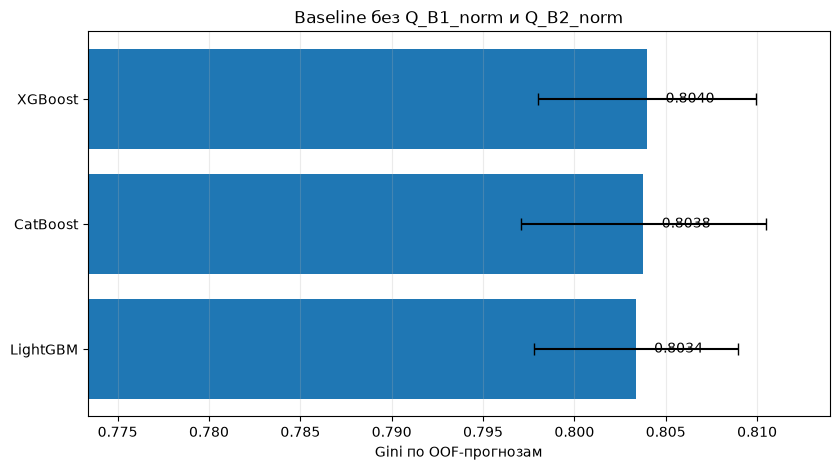

In [7]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
таблица_графика = ЛИДЕРБОРД.sort_values("Gini", ascending=True)

ax.barh(
    таблица_графика["Модель"],
    таблица_графика["Gini"],
    xerr=таблица_графика["Gini: std по фолдам"].fillna(0),
    capsize=4,
)
ax.set_xlabel("Gini по OOF-прогнозам")
ax.set_title("Baseline без Q_B1_norm и Q_B2_norm")
ax.grid(axis="x", alpha=0.25)

минимум = max(0.0, float(таблица_графика["Gini"].min()) - 0.03)
максимум = min(1.0, float(таблица_графика["Gini"].max()) + 0.01)
ax.set_xlim(минимум, максимум)

for i, значение in enumerate(таблица_графика["Gini"]):
    ax.text(значение + 0.001, i, f"{значение:.4f}", va="center")

plt.tight_layout()
plt.show()


# 5. Фиксация результата

## Исследовательский вопрос

Сохранили ли мы достаточно информации, чтобы воспроизвести baseline и отличить его от будущих экспериментов?


In [8]:
версии = {}
for пакет in [
    "numpy",
    "pandas",
    "scikit-learn",
    "pyxlsb",
    "catboost",
    "xgboost",
    "lightgbm",
    "matplotlib",
]:
    try:
        версии[пакет] = importlib_metadata.version(пакет)
    except importlib_metadata.PackageNotFoundError:
        версии[пакет] = "не установлена"

результат_для_json = {
    "исследовательский_вопрос": (
        "Какой честный уровень качества дают CatBoost, XGBoost и LightGBM "
        "после полного исключения Q_B1_norm и Q_B2_norm при одном протоколе оценки?"
    ),
    "dataset": {
        "путь": str(ПУТЬ_К_ДАТАСЕТУ),
        "sha256": фактический_sha256,
        "строк": int(len(данные)),
        "столбцов": int(данные.shape[1]),
    },
    "target": ЦЕЛЕВАЯ_ПЕРЕМЕННАЯ,
    "identifier": ИДЕНТИФИКАТОР,
    "исключённые_признаки": ИСКЛЮЧЁННЫЕ_ПРИЗНАКИ,
    "допустимые_признаки": ДОПУСТИМЫЕ_ПРИЗНАКИ,
    "число_допустимых_признаков": len(ДОПУСТИМЫЕ_ПРИЗНАКИ),
    "разбиение": {
        "доля_final_test": ДОЛЯ_ФИНАЛЬНОГО_TEST,
        "число_фолдов": ЧИСЛО_ФОЛДОВ,
        "seed": СЛУЧАЙНОЕ_ЗЕРНО,
        "рабочих_строк": int(len(индексы_работа)),
        "test_строк": int(len(индексы_test)),
        "sha256_индексов_работа": SHA_ИНДЕКСОВ_РАБОТА,
        "sha256_индексов_test": SHA_ИНДЕКСОВ_TEST,
        "final_test_использован_для_выбора": False,
    },
    "протокол": {
        "веса_классов": False,
        "optuna": False,
        "калибровка": False,
        "подбор_порога": False,
        "диагностический_порог": 0.5,
        "early_stopping_rounds": РАННЯЯ_ОСТАНОВКА,
        "доля_внутренней_validation": ДОЛЯ_ВНУТРЕННЕЙ_ВАЛИДАЦИИ,
        "early_stopping_protocol": "inner_validation_then_refit_outer_train",
    },
    "параметры_моделей": ПАРАМЕТРЫ_МОДЕЛЕЙ,
    "версии_библиотек": версии,
    "общее_время_эксперимента_сек": float(общее_время_эксперимента),
    "модели": {},
}

for название, результат in РЕЗУЛЬТАТЫ.items():
    результат_для_json["модели"][название] = {
        "итоговые_метрики": результат["итоговые_метрики"],
        "метрики_фолдов": результат["метрики_фолдов"].to_dict(orient="records"),
    }

путь_json = ПАПКА_ОТЧЁТОВ / "stage1_baseline_results.json"
путь_csv = ПАПКА_ОТЧЁТОВ / "stage1_baseline_leaderboard.csv"

путь_json.write_text(
    json.dumps(
        результат_для_json,
        ensure_ascii=False,
        indent=2,
        default=str,
    ),
    encoding="utf-8",
)

ЛИДЕРБОРД.to_csv(
    путь_csv,
    index=False,
    encoding="utf-8-sig",
)

print("Сохранено:")
print("-", путь_json)
print("-", путь_csv)


Сохранено:
- D:\Projects\komus-credit-risk\reports\generated\stage1_baseline_results.json
- D:\Projects\komus-credit-risk\reports\generated\stage1_baseline_leaderboard.csv


In [9]:
лидер = ЛИДЕРБОРД.iloc[0]
второй = ЛИДЕРБОРД.iloc[1]
разница_gini = float(лидер["Gini"] - второй["Gini"])

display(Markdown(f"""
# Итог Stage 1

## ФАКТЫ

- Лучший OOF Gini: **{лидер['Модель']} — {лидер['Gini']:.4f}**.
- ROC-AUC лидера: **{лидер['ROC-AUC']:.4f}**.
- PR-AUC лидера: **{лидер['PR-AUC']:.4f}**.
- Recall при диагностическом пороге 0.5: **{лидер['Recall']:.4f}**.
- Precision при диагностическом пороге 0.5: **{лидер['Precision']:.4f}**.
- Разница Gini между первым и вторым местом: **{разница_gini:.4f}**.
- Все модели использовали одни и те же **{len(ДОПУСТИМЫЕ_ПРИЗНАКИ)} признаков**, split и CV-фолды.
- Final test для выбора **не использовался**.

## ИНТЕРПРЕТАЦИЯ

Это новая точка отсчёта качества после полного исключения закрытых индексов. Она показывает, сколько сигнала остаётся в исходных разрешённых признаках **до** feature engineering и гиперпараметрического поиска.

Небольшую разницу между ведущими моделями нельзя автоматически объявлять содержательно значимой только по четвёртому знаку Gini.

## ОГРАНИЧЕНИЯ

- Random split не доказывает temporal stability.
- Порог 0.5 не является промышленным бизнес-порогом.
- Не проверяются новые признаки, веса классов, калибровка и Optuna.
- Final test остаётся закрытым.

## СЛЕДУЮЩИЙ ШАГ

После проверки сохранённых результатов формулируется **один следующий исследовательский вопрос**. До этого параметры и feature set не меняются.
"""))



# Итог Stage 1

## ФАКТЫ

- Лучший OOF Gini: **XGBoost — 0.8040**.
- ROC-AUC лидера: **0.9020**.
- PR-AUC лидера: **0.5993**.
- Recall при диагностическом пороге 0.5: **0.3684**.
- Precision при диагностическом пороге 0.5: **0.7123**.
- Разница Gini между первым и вторым местом: **0.0002**.
- Все модели использовали одни и те же **47 признаков**, split и CV-фолды.
- Final test для выбора **не использовался**.

## ИНТЕРПРЕТАЦИЯ

Это новая точка отсчёта качества после полного исключения закрытых индексов. Она показывает, сколько сигнала остаётся в исходных разрешённых признаках **до** feature engineering и гиперпараметрического поиска.

Небольшую разницу между ведущими моделями нельзя автоматически объявлять содержательно значимой только по четвёртому знаку Gini.

## ОГРАНИЧЕНИЯ

- Random split не доказывает temporal stability.
- Порог 0.5 не является промышленным бизнес-порогом.
- Не проверяются новые признаки, веса классов, калибровка и Optuna.
- Final test остаётся закрытым.

## СЛЕДУЮЩИЙ ШАГ

После проверки сохранённых результатов формулируется **один следующий исследовательский вопрос**. До этого параметры и feature set не меняются.
